In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
output_folder = "/kaggle/working/Output_Images"

os.makedirs(output_folder, exist_ok=True)

print("Output folder created successfully!")

Output folder created successfully!


In [3]:
input_folder = "/kaggle/input/datasets/grobibib/smartdociqa-d26-modified/Dataset SmartDoc-QA-modified-D26-Nokia"

image_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Total Images:", len(image_files))

# Use first 10 images
image_files = image_files[:10]

print(image_files)

Total Images: 60
['M_Img_WP_D26_L2_r35_a-10_b-5.jpg', 'M_Img_WP_D26_L2_r35_a-10_b-5_Mb2.jpg', 'M_Img_WP_D26_L2_r35_a-10_b-5_Ob820.jpg', 'M_Img_WP_D26_L2_r35_a-10_b-5_Ob940.jpg', 'M_Img_WP_D26_L2_r35_a-10_b5.jpg', 'M_Img_WP_D26_L2_r35_a-10_b5_Mb2.jpg', 'M_Img_WP_D26_L2_r35_a-10_b5_Ob820.jpg', 'M_Img_WP_D26_L2_r35_a-10_b5_Ob940.jpg', 'M_Img_WP_D26_L2_r35_a-5_b10.jpg', 'M_Img_WP_D26_L2_r35_a-5_b10_Mb2.jpg']


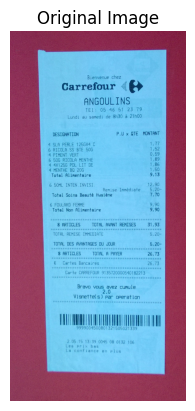

In [4]:
image_path = os.path.join(input_folder, image_files[0])

image = cv2.imread(image_path)

original = image.copy()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

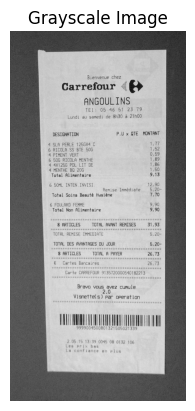

In [5]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

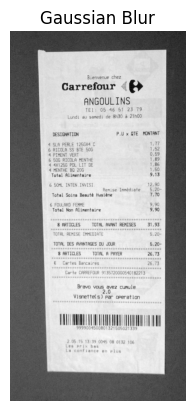

In [6]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

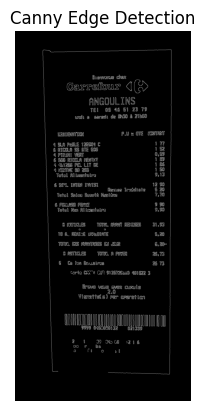

In [7]:
edges = cv2.Canny(blur, 75, 200)

plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

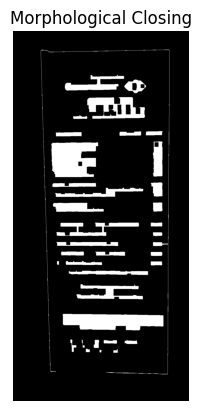

In [8]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))

morph = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=3
)

plt.imshow(morph, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")
plt.show()

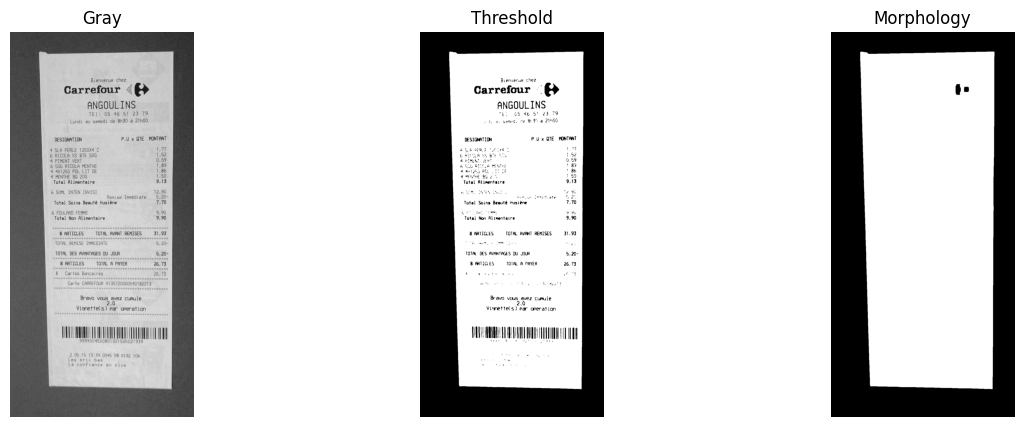

In [9]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

# Otsu Threshold
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))

morph = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray,cmap='gray')
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(thresh,cmap='gray')
plt.title("Threshold")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(morph,cmap='gray')
plt.title("Morphology")
plt.axis("off")

plt.show()

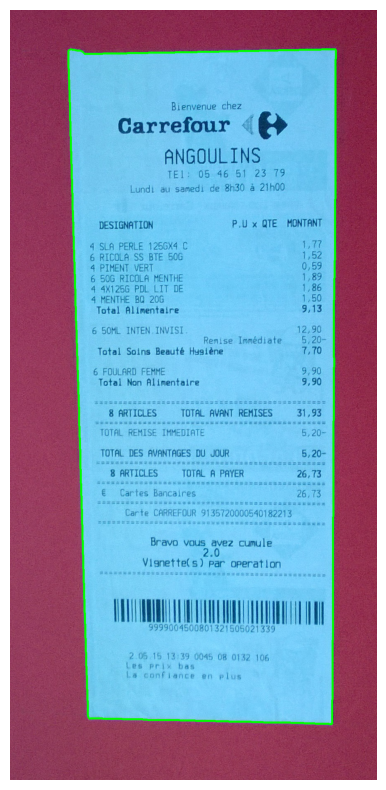

In [10]:
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

largest = max(contours, key=cv2.contourArea)

result = original.copy()

cv2.drawContours(result,[largest],-1,(0,255,0),4)

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_folder = "/kaggle/input/datasets/grobibib/smartdociqa-d26-modified/Dataset SmartDoc-QA-modified-D26-Nokia"

output_folder = "/kaggle/working/Output_Images"

os.makedirs(output_folder, exist_ok=True)

image_files = sorted([
    f for f in os.listdir(input_folder)
    if f.endswith((".jpg",".png",".jpeg"))
])

# Process only first 10 images
image_files = image_files[:10]

print("Processing", len(image_files), "images...")

Processing 10 images...


In [12]:
for filename in image_files:

    image_path = os.path.join(input_folder, filename)

    image = cv2.imread(image_path)

    original = image.copy()


    # Grayscale


    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


    # Gaussian Blur


    blur = cv2.GaussianBlur(gray,(5,5),0)


    # Canny


    edges = cv2.Canny(blur,75,200)


    # Threshold


    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )


    # Morphology


    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (9,9)
    )

    morph = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )


    # Find Largest Contour

    contours,_ = cv2.findContours(
        morph,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    result = original.copy()

    if len(contours) > 0:

        largest = max(contours,key=cv2.contourArea)

        cv2.drawContours(
            result,
            [largest],
            -1,
            (0,255,0),
            4
        )

    # Save Images


    name = os.path.splitext(filename)[0]

    cv2.imwrite(
        os.path.join(output_folder,f"{name}_original.jpg"),
        original
    )

    cv2.imwrite(
        os.path.join(output_folder,f"{name}_edges.jpg"),
        edges
    )

    cv2.imwrite(
        os.path.join(output_folder,f"{name}_morph.jpg"),
        morph
    )

    cv2.imwrite(
        os.path.join(output_folder,f"{name}_boundary.jpg"),
        result
    )

print("Processing Completed!")

Processing Completed!


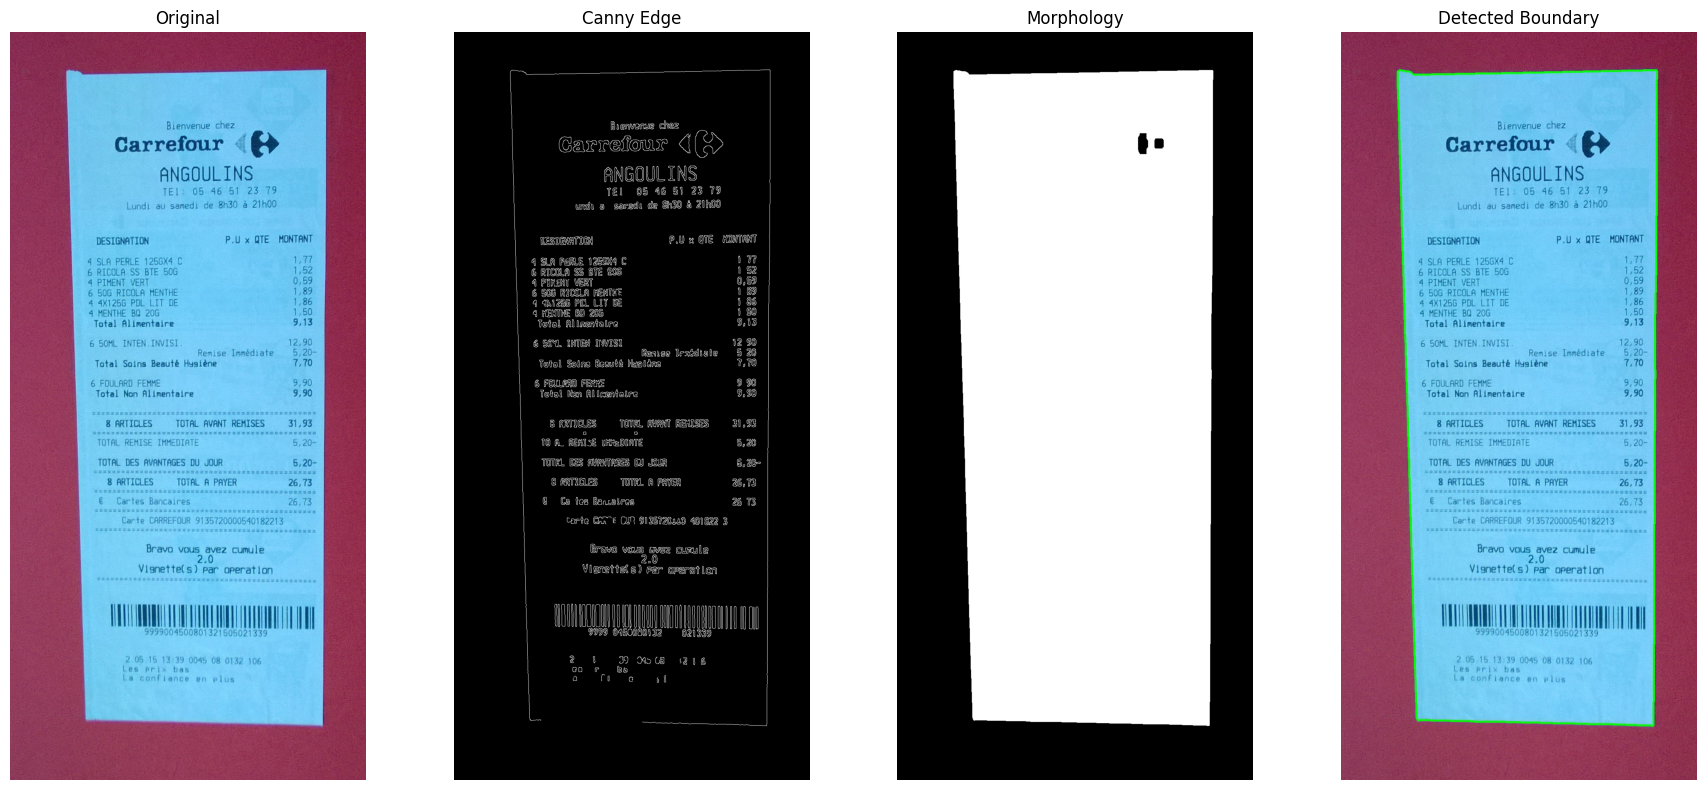

In [13]:
sample = image_files[0]

name = os.path.splitext(sample)[0]

original = cv2.imread(
    os.path.join(output_folder,f"{name}_original.jpg")
)

edges = cv2.imread(
    os.path.join(output_folder,f"{name}_edges.jpg"),
    0
)

morph = cv2.imread(
    os.path.join(output_folder,f"{name}_morph.jpg"),
    0
)

boundary = cv2.imread(
    os.path.join(output_folder,f"{name}_boundary.jpg")
)

plt.figure(figsize=(18,8))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(original,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(edges,cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(morph,cmap="gray")
plt.title("Morphology")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(boundary,cv2.COLOR_BGR2RGB))
plt.title("Detected Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import shutil
import os

output_folder = "/kaggle/working/Output_Images"
zip_path = "/kaggle/working/Output_Images"

# Create ZIP
shutil.make_archive(zip_path, 'zip', output_folder)

print("ZIP file created successfully!")
print("Location:", zip_path + ".zip")

ZIP file created successfully!
Location: /kaggle/working/Output_Images.zip
